
# Regression and Testing — тестова проба

Това е упражнение в Jupyter Notebook.  
Пробваме линейна зависимост, шум в данните, regression линия, MSE и basic tests.



## 1. Идеална линейна зависимост

Тук данните са създадени по формулата:

`y = 5x - 2`

Няма шум, затова всички точки лежат точно върху правата линия.


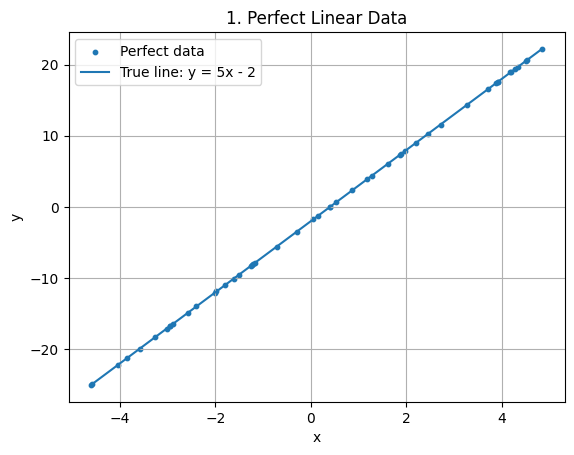


## 2. Данни със слаб шум

Тук добавяме малък случаен шум.  
Точките вече не са идеално върху линията, но пак са близо до нея.

Regression линията почти съвпада с истинската линия.


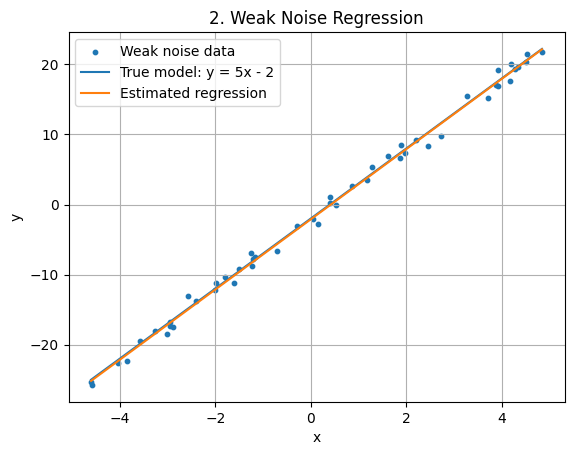


## 3. Данни със силен шум

Тук добавяме много по-силен шум.  
Точките са разхвърляни, но regression линията пак се опитва да намери общата тенденция.


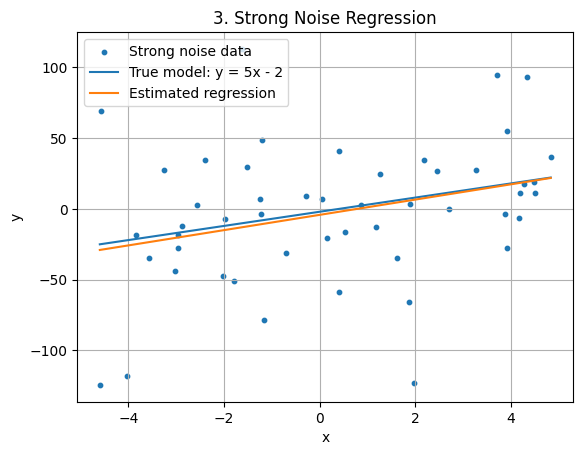


## 4. Сравнение на модели

Сравняваме три линии:

- Manual model: `y = 1x + 0`
- True model: `y = 5x - 2`
- Estimated regression: линията, която Python намира автоматично

Това показва кой модел пасва най-добре на данните.


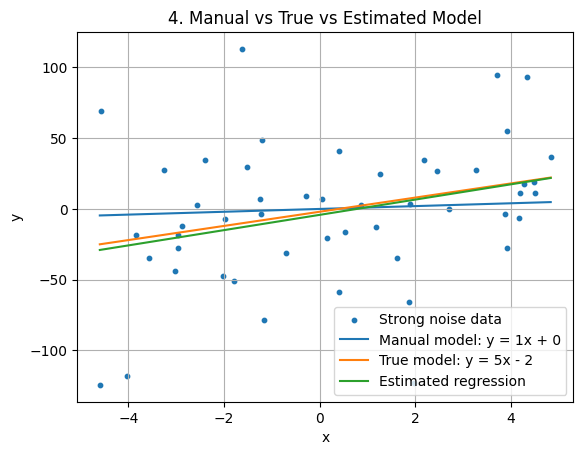


## 5. MSE сравнение

MSE означава **Mean Squared Error**.

Колкото по-малко е MSE, толкова по-добре моделът пасва на данните.


,Case,Model,MSE
0,Perfect data / True model,y = 5x - 2,0.000000
1,Weak noise / Manual model,y = 1x + 0,132.269407
2,Weak noise / True model,y = 5x - 2,0.786217
3,Weak noise / Estimated regression,y = 5.01x + -2.11,0.773712
4,Strong noise / Manual model,y = 1x + 0,2383.949136
5,Strong noise / True model,y = 5x - 2,2224.285293
6,Strong noise / Estimated regression,y = 5.39x + -4.20,2218.686253



## 6. Basic testing

Накрая правим малки проверки с `assert`.

При слаб шум очакваме наклонът да е близо до 5.  
При силен шум поне очакваме линията да има положителна посока.


Tests passed
Weak noise slope: 5.011540983515519
Strong noise slope: 5.390815322156745


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.random.seed(42)

def note(text):
    display(Markdown(text))

note("""
# Regression and Testing — тестова проба

Това е упражнение в Jupyter Notebook.  
Пробваме линейна зависимост, шум в данните, regression линия, MSE и basic tests.
""")

# Данни
x = np.linspace(-5, 5, 500)
x = np.random.choice(x, 50)

true_y = 5 * x - 2

weak_noise = np.random.normal(loc=0, scale=1, size=len(x))
strong_noise = np.random.normal(loc=0, scale=50, size=len(x))

y_weak = true_y + weak_noise
y_strong = true_y + strong_noise

# Модели
manual_a = 1
manual_b = 0
manual_prediction = manual_a * x + manual_b

true_prediction = 5 * x - 2

weak_a, weak_b = np.polyfit(x, y_weak, 1)
weak_prediction = weak_a * x + weak_b

strong_a, strong_b = np.polyfit(x, y_strong, 1)
strong_prediction = strong_a * x + strong_b

def mse(real, predicted):
    return np.mean((real - predicted) ** 2)

sorted_indices = np.argsort(x)
x_sorted = x[sorted_indices]

# Graph 1
note("""
## 1. Идеална линейна зависимост

Тук данните са създадени по формулата:

`y = 5x - 2`

Няма шум, затова всички точки лежат точно върху правата линия.
""")

plt.scatter(x, true_y, s=10, label="Perfect data")
plt.plot(x_sorted, true_prediction[sorted_indices], label="True line: y = 5x - 2")
plt.title("1. Perfect Linear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Graph 2
note("""
## 2. Данни със слаб шум

Тук добавяме малък случаен шум.  
Точките вече не са идеално върху линията, но пак са близо до нея.

Regression линията почти съвпада с истинската линия.
""")

plt.scatter(x, y_weak, s=10, label="Weak noise data")
plt.plot(x_sorted, true_prediction[sorted_indices], label="True model: y = 5x - 2")
plt.plot(x_sorted, weak_prediction[sorted_indices], label="Estimated regression")
plt.title("2. Weak Noise Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Graph 3
note("""
## 3. Данни със силен шум

Тук добавяме много по-силен шум.  
Точките са разхвърляни, но regression линията пак се опитва да намери общата тенденция.
""")

plt.scatter(x, y_strong, s=10, label="Strong noise data")
plt.plot(x_sorted, true_prediction[sorted_indices], label="True model: y = 5x - 2")
plt.plot(x_sorted, strong_prediction[sorted_indices], label="Estimated regression")
plt.title("3. Strong Noise Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Graph 4
note("""
## 4. Сравнение на модели

Сравняваме три линии:

- Manual model: `y = 1x + 0`
- True model: `y = 5x - 2`
- Estimated regression: линията, която Python намира автоматично

Това показва кой модел пасва най-добре на данните.
""")

plt.scatter(x, y_strong, s=10, label="Strong noise data")
plt.plot(x_sorted, manual_prediction[sorted_indices], label="Manual model: y = 1x + 0")
plt.plot(x_sorted, true_prediction[sorted_indices], label="True model: y = 5x - 2")
plt.plot(x_sorted, strong_prediction[sorted_indices], label="Estimated regression")
plt.title("4. Manual vs True vs Estimated Model")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# MSE table
comparison = pd.DataFrame({
    "Case": [
        "Perfect data / True model",
        "Weak noise / Manual model",
        "Weak noise / True model",
        "Weak noise / Estimated regression",
        "Strong noise / Manual model",
        "Strong noise / True model",
        "Strong noise / Estimated regression"
    ],
    "Model": [
        "y = 5x - 2",
        "y = 1x + 0",
        "y = 5x - 2",
        f"y = {weak_a:.2f}x + {weak_b:.2f}",
        "y = 1x + 0",
        "y = 5x - 2",
        f"y = {strong_a:.2f}x + {strong_b:.2f}"
    ],
    "MSE": [
        mse(true_y, true_prediction),
        mse(y_weak, manual_prediction),
        mse(y_weak, true_prediction),
        mse(y_weak, weak_prediction),
        mse(y_strong, manual_prediction),
        mse(y_strong, true_prediction),
        mse(y_strong, strong_prediction)
    ]
})

note("""
## 5. MSE сравнение

MSE означава **Mean Squared Error**.

Колкото по-малко е MSE, толкова по-добре моделът пасва на данните.
""")

display(comparison)

# Tests
note("""
## 6. Basic testing

Накрая правим малки проверки с `assert`.

При слаб шум очакваме наклонът да е близо до 5.  
При силен шум поне очакваме линията да има положителна посока.
""")

assert weak_a > 4 and weak_a < 6
assert strong_a > 0

print("Tests passed")
print("Weak noise slope:", weak_a)
print("Strong noise slope:", strong_a)